# Schräger Wurf / Wurfparabel — Simulation

Simulation der Wurfparabel in Abhängigkeit der drei Parameter

| Symbol | Bedeutung | Einheit |
|---|---|---|
| $h_0$ | Anfangshöhe | m |
| $v_0$ | Anfangsgeschwindigkeit | m/s |
| $\alpha$ | Abwurfwinkel gegen die Horizontale | ° |

## Bewegungsgleichungen

Der schräge Wurf ist die Überlagerung einer gleichförmigen Bewegung in $x$-Richtung
und eines freien Falls in $y$-Richtung (Luftwiderstand wird vernachlässigt):

$$x(t) = v_0 \cos(\alpha)\, t \qquad\qquad y(t) = h_0 + v_0 \sin(\alpha)\, t - \tfrac{1}{2} g t^2$$

$$v_x(t) = v_0\cos(\alpha) = \text{const.} \qquad\qquad v_y(t) = v_0 \sin(\alpha) - g t$$

Eliminiert man $t$, erhält man die **Bahnkurve** (eine nach unten geöffnete Parabel):

$$y(x) = h_0 + \tan(\alpha)\, x - \frac{g}{2 v_0^2 \cos^2(\alpha)}\, x^2$$

## Kenngrößen

* **Steigzeit** (bis $v_y = 0$): $\;t_s = \dfrac{v_0 \sin\alpha}{g}$
* **Maximale Höhe**: $\;h_{max} = h_0 + \dfrac{(v_0 \sin\alpha)^2}{2g}$
* **Flugzeit** (bis $y = 0$, Lösung der quadratischen Gleichung):
  $\;t_f = \dfrac{v_0\sin\alpha + \sqrt{(v_0\sin\alpha)^2 + 2 g h_0}}{g}$
* **Wurfweite**: $\;x_w = v_0 \cos\alpha \cdot t_f$

Für $h_0 = 0$ vereinfacht sich die Weite zur bekannten Formel $x_w = \dfrac{v_0^2 \sin(2\alpha)}{g}$
mit dem optimalen Winkel $45°$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

G = 9.81  # Erdbeschleunigung in m/s^2

## 1. Kernfunktionen

`wurf(...)` berechnet die komplette Bahnkurve, `kennzahlen(...)` die charakteristischen Größen.
Beide arbeiten mit den drei Parametern `h0`, `v0`, `alpha` (in Grad).

In [2]:
def flugzeit(h0, v0, alpha, g=G):
    """Zeit vom Abwurf bis zum Auftreffen auf y = 0 (in s)."""
    a = np.radians(alpha)
    vy0 = v0 * np.sin(a)
    return (vy0 + np.sqrt(vy0**2 + 2 * g * h0)) / g


def wurf(h0, v0, alpha, g=G, n=400):
    """Bahnkurve des schrägen Wurfs.

    Rückgabe: t, x, y, vx, vy — jeweils Arrays vom Abwurf bis zum Auftreffpunkt.
    """
    a = np.radians(alpha)
    t = np.linspace(0, flugzeit(h0, v0, alpha, g), n)
    x = v0 * np.cos(a) * t
    y = h0 + v0 * np.sin(a) * t - 0.5 * g * t**2
    vx = np.full_like(t, v0 * np.cos(a))
    vy = v0 * np.sin(a) - g * t
    return t, x, y, vx, vy


def kennzahlen(h0, v0, alpha, g=G):
    """Charakteristische Größen des Wurfs als dict."""
    a = np.radians(alpha)
    vx0, vy0 = v0 * np.cos(a), v0 * np.sin(a)
    tf = flugzeit(h0, v0, alpha, g)
    ts = vy0 / g                      # Steigzeit (negativ bei Abwurf nach unten)
    vy_end = vy0 - g * tf
    return {
        "Steigzeit t_s [s]":        max(ts, 0.0),
        "Flugzeit t_f [s]":         tf,
        "Wurfweite x_w [m]":        vx0 * tf,
        "max. Höhe h_max [m]":      h0 + vy0**2 / (2 * g) if ts > 0 else h0,
        "Auftreffgeschw. [m/s]":    np.hypot(vx0, vy_end),
        "Auftreffwinkel [°]":       abs(np.degrees(np.arctan2(vy_end, vx0))),
    }

In [3]:
def plot_wuerfe(szenarien, titel, label_fmt="{h0:.0f} m | {v0:.0f} m/s | {alpha:.0f}°"):
    """Zeichnet mehrere Wurfparabeln (Liste von (h0, v0, alpha)-Tupeln) in ein Diagramm."""
    fig, ax = plt.subplots()
    farben = plt.cm.viridis(np.linspace(0, 0.9, len(szenarien)))

    for (h0, v0, alpha), farbe in zip(szenarien, farben):
        _, x, y, _, _ = wurf(h0, v0, alpha)
        k = kennzahlen(h0, v0, alpha)
        label = label_fmt.format(h0=h0, v0=v0, alpha=alpha)
        ax.plot(x, y, color=farbe, lw=2,
                label=f"{label}  →  x_w = {k['Wurfweite x_w [m]']:.1f} m")
        ax.plot(x[np.argmax(y)], y.max(), "o", color=farbe, ms=5)   # Scheitelpunkt
        ax.plot(x[-1], 0, "v", color=farbe, ms=7)                   # Auftreffpunkt

    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("Weite x [m]")
    ax.set_ylabel("Höhe y [m]")
    ax.set_title(titel)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    plt.show()


def tabelle(szenarien):
    """Kennzahlen mehrerer Szenarien als Texttabelle ausgeben."""
    spalten = list(kennzahlen(1, 1, 45).keys())
    kopf = f"{'h0 [m]':>7}{'v0 [m/s]':>10}{'alpha [°]':>11}" + "".join(f"{s:>24}" for s in spalten)
    print(kopf)
    print("-" * len(kopf))
    for h0, v0, alpha in szenarien:
        k = kennzahlen(h0, v0, alpha)
        print(f"{h0:>7.1f}{v0:>10.1f}{alpha:>11.1f}" + "".join(f"{k[s]:>24.2f}" for s in spalten))

## 2. Referenzwurf

Ein einzelner Wurf mit Bahnkurve, Geschwindigkeitsverlauf und Kennzahlen.

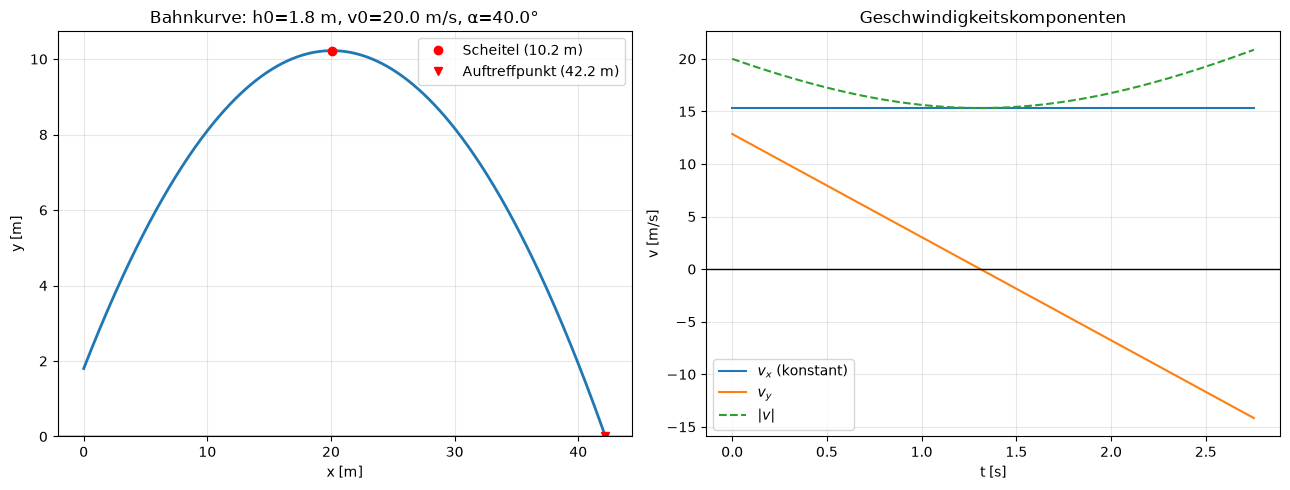

Steigzeit t_s [s]            1.31
Flugzeit t_f [s]             2.75
Wurfweite x_w [m]           42.20
max. Höhe h_max [m]         10.22
Auftreffgeschw. [m/s]       20.86
Auftreffwinkel [°]          42.75


In [4]:
h0, v0, alpha = 1.8, 20.0, 40.0     # ← hier die drei Parameter frei verändern

t, x, y, vx, vy = wurf(h0, v0, alpha)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(x, y, lw=2)
ax1.plot(x[np.argmax(y)], y.max(), "ro", label=f"Scheitel ({y.max():.1f} m)")
ax1.plot(x[-1], 0, "rv", label=f"Auftreffpunkt ({x[-1]:.1f} m)")
ax1.axhline(0, color="k", lw=1)
ax1.set(xlabel="x [m]", ylabel="y [m]",
        title=f"Bahnkurve: h0={h0} m, v0={v0} m/s, α={alpha}°", ylim=(0, None))
ax1.legend()

ax2.plot(t, vx, label="$v_x$ (konstant)")
ax2.plot(t, vy, label="$v_y$")
ax2.plot(t, np.hypot(vx, vy), "--", label="$|v|$")
ax2.axhline(0, color="k", lw=1)
ax2.set(xlabel="t [s]", ylabel="v [m/s]", title="Geschwindigkeitskomponenten")
ax2.legend()

plt.tight_layout()
plt.show()

for name, wert in kennzahlen(h0, v0, alpha).items():
    print(f"{name:<24} {wert:8.2f}")

## 3. Szenario A — Variation des Abwurfwinkels $\alpha$

$h_0$ und $v_0$ bleiben fest. Gut zu sehen: flache und steile Würfe mit komplementären Winkeln
($30°/60°$) haben bei $h_0 = 0$ die **gleiche Weite**, bei $h_0 > 0$ gewinnt der flachere Wurf.

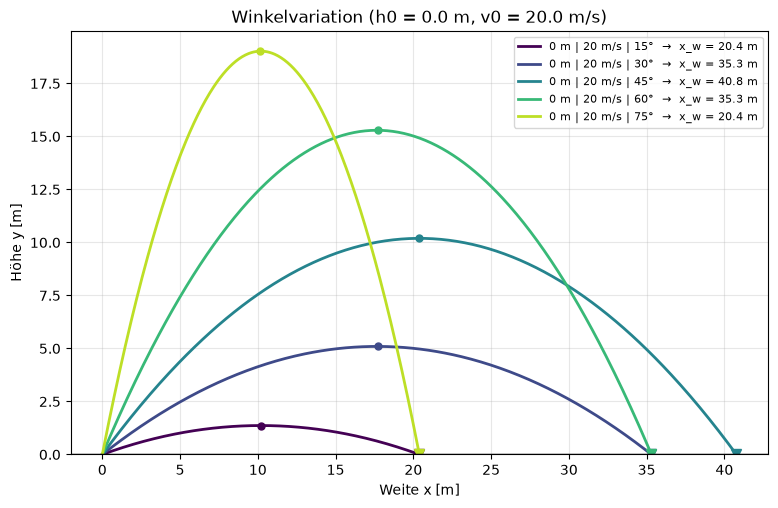

 h0 [m]  v0 [m/s]  alpha [°]       Steigzeit t_s [s]        Flugzeit t_f [s]       Wurfweite x_w [m]     max. Höhe h_max [m]   Auftreffgeschw. [m/s]      Auftreffwinkel [°]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0.0      20.0       15.0                    0.53                    1.06                   20.39                    1.37                   20.00                   15.00
    0.0      20.0       30.0                    1.02                    2.04                   35.31                    5.10                   20.00                   30.00
    0.0      20.0       45.0                    1.44                    2.88                   40.77                   10.19                   20.00                   45.00
    0.0      20.0       60.0                    1.77                    3.53                   35.31                   15.29           

In [5]:
h0, v0 = 0.0, 20.0
winkel = [15, 30, 45, 60, 75]
szenarien_A = [(h0, v0, a) for a in winkel]

plot_wuerfe(szenarien_A, f"Winkelvariation (h0 = {h0} m, v0 = {v0} m/s)")
tabelle(szenarien_A)

## 4. Szenario B — Variation der Anfangsgeschwindigkeit $v_0$

Winkel und Höhe fest. Die Wurfweite wächst bei $h_0 = 0$ **quadratisch** mit $v_0$:
doppelte Geschwindigkeit → vierfache Weite.

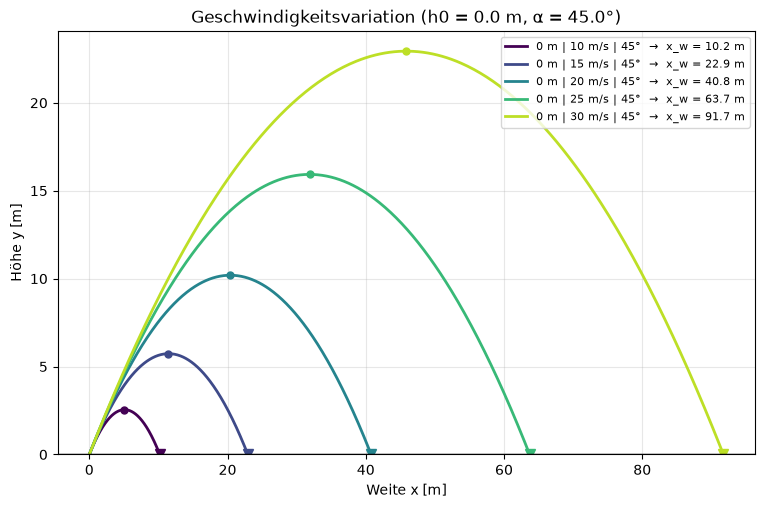

 h0 [m]  v0 [m/s]  alpha [°]       Steigzeit t_s [s]        Flugzeit t_f [s]       Wurfweite x_w [m]     max. Höhe h_max [m]   Auftreffgeschw. [m/s]      Auftreffwinkel [°]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0.0      10.0       45.0                    0.72                    1.44                   10.19                    2.55                   10.00                   45.00
    0.0      15.0       45.0                    1.08                    2.16                   22.94                    5.73                   15.00                   45.00
    0.0      20.0       45.0                    1.44                    2.88                   40.77                   10.19                   20.00                   45.00
    0.0      25.0       45.0                    1.80                    3.60                   63.71                   15.93           

In [6]:
h0, alpha = 0.0, 45.0
geschwindigkeiten = [10, 15, 20, 25, 30]
szenarien_B = [(h0, v, alpha) for v in geschwindigkeiten]

plot_wuerfe(szenarien_B, f"Geschwindigkeitsvariation (h0 = {h0} m, α = {alpha}°)")
tabelle(szenarien_B)

print("\nVerhältnis Wurfweite / v0² (bei h0 = 0 konstant):")
for v in geschwindigkeiten:
    xw = kennzahlen(h0, v, alpha)["Wurfweite x_w [m]"]
    print(f"  v0 = {v:>4} m/s → x_w = {xw:6.2f} m → x_w/v0² = {xw/v**2:.4f}")

## 5. Szenario C — Variation der Anfangshöhe $h_0$

$v_0$ und $\alpha$ fest. Eine größere Abwurfhöhe verlängert Flugzeit und Weite — aber nur
unterproportional, weil die zusätzliche Fallzeit mit $\sqrt{h_0}$ wächst.

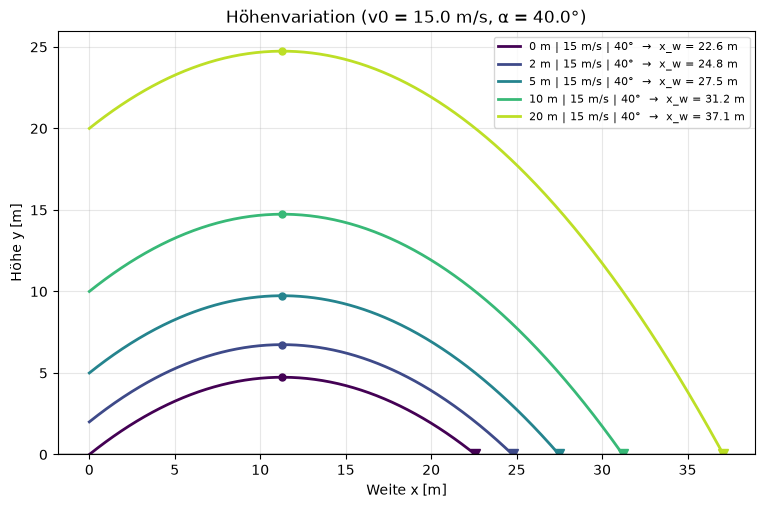

 h0 [m]  v0 [m/s]  alpha [°]       Steigzeit t_s [s]        Flugzeit t_f [s]       Wurfweite x_w [m]     max. Höhe h_max [m]   Auftreffgeschw. [m/s]      Auftreffwinkel [°]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0.0      15.0       40.0                    0.98                    1.97                   22.59                    4.74                   15.00                   40.00
    2.0      15.0       40.0                    0.98                    2.15                   24.76                    6.74                   16.26                   45.02
    5.0      15.0       40.0                    0.98                    2.39                   27.48                    9.74                   17.97                   50.26
   10.0      15.0       40.0                    0.98                    2.72                   31.21                   14.74           

In [7]:
v0, alpha = 15.0, 40.0
hoehen = [0, 2, 5, 10, 20]
szenarien_C = [(h, v0, alpha) for h in hoehen]

plot_wuerfe(szenarien_C, f"Höhenvariation (v0 = {v0} m/s, α = {alpha}°)")
tabelle(szenarien_C)

## 6. Optimaler Abwurfwinkel

Nur für $h_0 = 0$ ist $45°$ optimal. Aus erhöhter Position ist der beste Winkel **flacher**:

$$\sin(\alpha_{opt}) = \frac{1}{\sqrt{2 + \dfrac{2 g h_0}{v_0^2}}}
\qquad\Longleftrightarrow\qquad
\alpha_{opt} = \arccos\sqrt{\frac{v_0^2 + g h_0}{v_0^2 + 2 g h_0}}$$

Unten wird die Formel mit einer numerischen Suche verglichen.

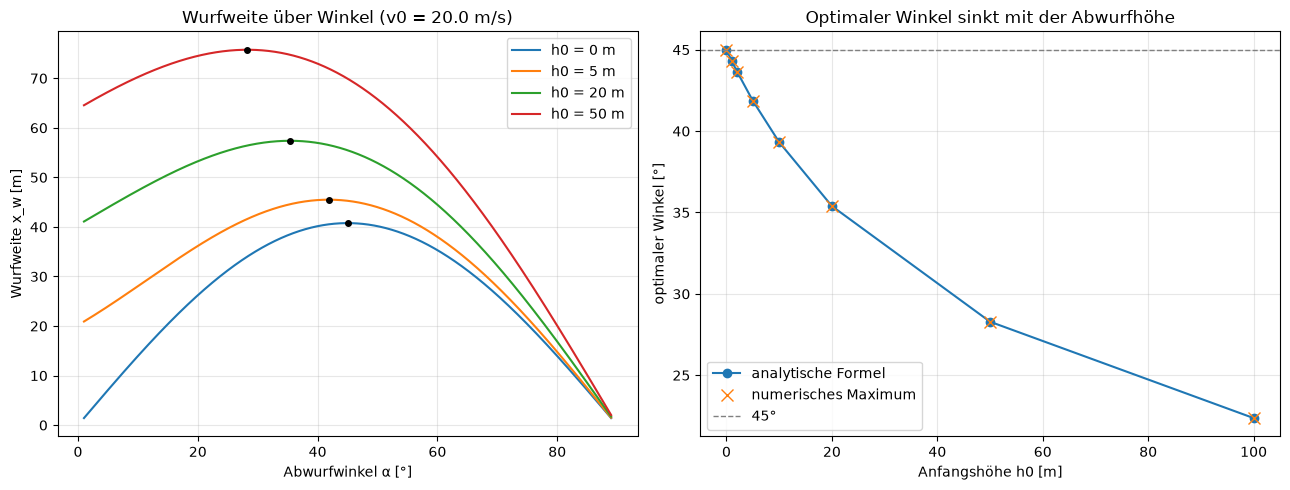

  h0 [m]   α_opt [°]    x_w(α_opt) [m]    x_w(45°) [m]
       0       45.00             40.77           40.77
       1       44.31             41.76           41.75
       2       43.66             42.73           42.69
       5       41.86             45.50           45.28
      10       39.32             49.78           49.08
      20       35.39             57.39           55.47
      50       28.29             75.76           69.93
     100       22.37             99.08           87.42


In [8]:
def alpha_optimal(h0, v0, g=G):
    """Analytisch optimaler Abwurfwinkel für maximale Wurfweite (in Grad)."""
    return np.degrees(np.arcsin(1 / np.sqrt(2 + 2 * g * h0 / v0**2)))


v0 = 20.0
hoehen = np.array([0, 1, 2, 5, 10, 20, 50, 100])
winkel_fein = np.linspace(1, 89, 8801)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for h0 in [0, 5, 20, 50]:
    weiten = [kennzahlen(h0, v0, a)["Wurfweite x_w [m]"] for a in winkel_fein]
    ax1.plot(winkel_fein, weiten, label=f"h0 = {h0} m")
    ax1.plot(winkel_fein[np.argmax(weiten)], max(weiten), "k.", ms=8)
ax1.set(xlabel="Abwurfwinkel α [°]", ylabel="Wurfweite x_w [m]",
        title=f"Wurfweite über Winkel (v0 = {v0} m/s)")
ax1.legend()

ax2.plot(hoehen, [alpha_optimal(h, v0) for h in hoehen], "o-", label="analytische Formel")
ax2.plot(hoehen,
         [winkel_fein[np.argmax([kennzahlen(h, v0, a)["Wurfweite x_w [m]"] for a in winkel_fein])]
          for h in hoehen],
         "x", ms=9, label="numerisches Maximum")
ax2.axhline(45, color="gray", ls="--", lw=1, label="45°")
ax2.set(xlabel="Anfangshöhe h0 [m]", ylabel="optimaler Winkel [°]",
        title="Optimaler Winkel sinkt mit der Abwurfhöhe")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"{'h0 [m]':>8}{'α_opt [°]':>12}{'x_w(α_opt) [m]':>18}{'x_w(45°) [m]':>16}")
for h0 in hoehen:
    ao = alpha_optimal(h0, v0)
    print(f"{h0:>8.0f}{ao:>12.2f}"
          f"{kennzahlen(h0, v0, ao)['Wurfweite x_w [m]']:>18.2f}"
          f"{kennzahlen(h0, v0, 45)['Wurfweite x_w [m]']:>16.2f}")

## 7. Parameterfeld — alle drei Größen auf einen Blick

Heatmaps der Wurfweite in Abhängigkeit von je zwei Parametern.

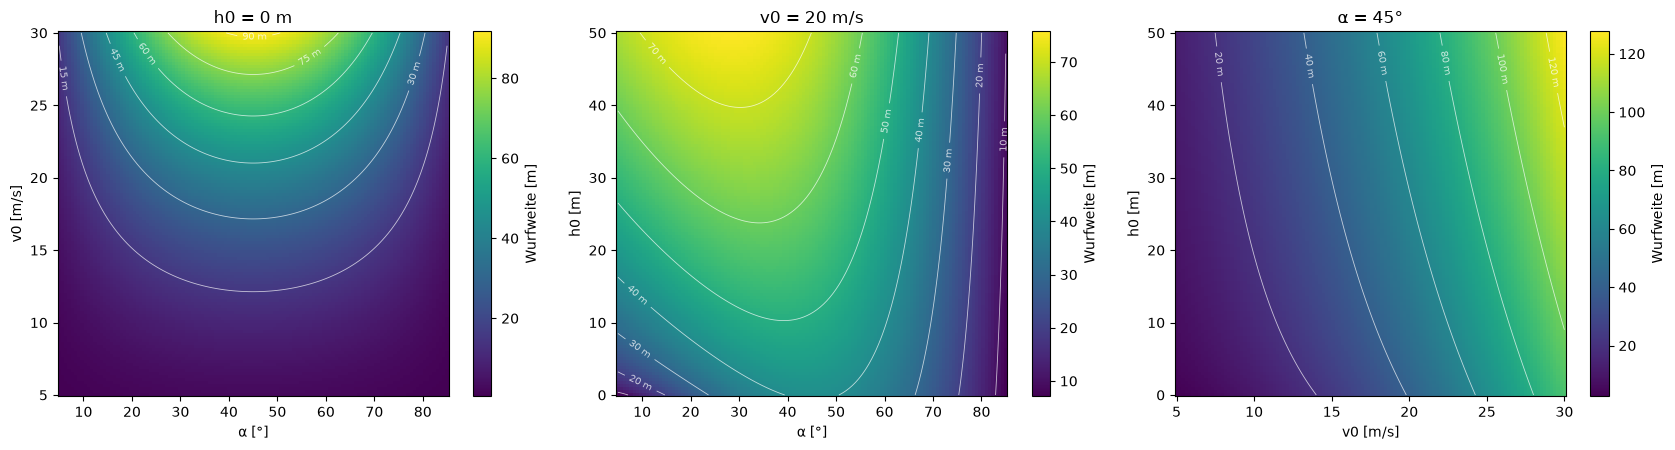

In [9]:
def heatmap(ax, X, Y, Z, xlabel, ylabel, titel):
    bild = ax.pcolormesh(X, Y, Z, shading="auto", cmap="viridis")
    linien = ax.contour(X, Y, Z, colors="white", linewidths=0.6, alpha=0.7)
    ax.clabel(linien, inline=True, fontsize=7, fmt="%.0f m")
    ax.set(xlabel=xlabel, ylabel=ylabel, title=titel)
    ax.grid(False)
    plt.colorbar(bild, ax=ax, label="Wurfweite [m]")


weite = np.vectorize(lambda h0, v0, a: kennzahlen(h0, v0, a)["Wurfweite x_w [m]"])

alphas = np.linspace(5, 85, 120)
v0s = np.linspace(5, 30, 120)
h0s = np.linspace(0, 50, 120)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

A, V = np.meshgrid(alphas, v0s)
heatmap(axes[0], A, V, weite(0.0, V, A), "α [°]", "v0 [m/s]", "h0 = 0 m")

A, H = np.meshgrid(alphas, h0s)
heatmap(axes[1], A, H, weite(H, 20.0, A), "α [°]", "h0 [m]", "v0 = 20 m/s")

V, H = np.meshgrid(v0s, h0s)
heatmap(axes[2], V, H, weite(H, V, 45.0), "v0 [m/s]", "h0 [m]", "α = 45°")

plt.tight_layout()
plt.show()

## 8. Interaktiv

Mit `ipywidgets` lassen sich die drei Parameter per Schieberegler verändern
(falls das Paket fehlt: `pip install ipywidgets`, sonst wird ein statisches Beispiel gezeigt).

ipywidgets nicht installiert — statisches Beispiel:


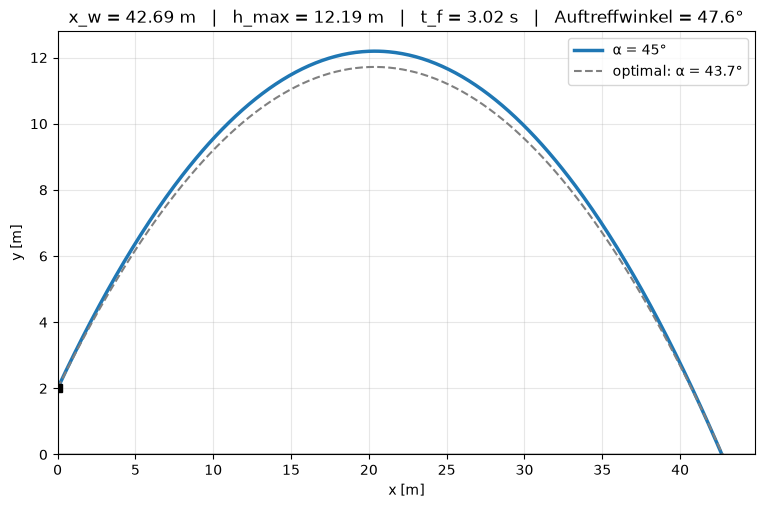

In [10]:
def zeige(h0=2.0, v0=20.0, alpha=45.0, vergleich_45=True):
    _, x, y, _, _ = wurf(h0, v0, alpha)
    k = kennzahlen(h0, v0, alpha)

    fig, ax = plt.subplots()
    ax.plot(x, y, lw=2.5, label=f"α = {alpha:.0f}°")
    if vergleich_45 and abs(alpha - alpha_optimal(h0, v0)) > 0.5:
        ao = alpha_optimal(h0, v0)
        _, xo, yo, _, _ = wurf(h0, v0, ao)
        ax.plot(xo, yo, "--", lw=1.5, color="gray", label=f"optimal: α = {ao:.1f}°")
    ax.axhline(0, color="k", lw=1)
    ax.plot(0, h0, "ks", ms=6)
    ax.set(xlabel="x [m]", ylabel="y [m]", ylim=(0, None),
           xlim=(0, max(x.max(), 1) * 1.05),
           title=(f"x_w = {k['Wurfweite x_w [m]']:.2f} m   |   "
                  f"h_max = {k['max. Höhe h_max [m]']:.2f} m   |   "
                  f"t_f = {k['Flugzeit t_f [s]']:.2f} s   |   "
                  f"Auftreffwinkel = {k['Auftreffwinkel [°]']:.1f}°"))
    ax.legend()
    plt.show()


try:
    from ipywidgets import interact, FloatSlider

    interact(zeige,
             h0=FloatSlider(value=2.0, min=0.0, max=50.0, step=0.5, description="h0 [m]"),
             v0=FloatSlider(value=20.0, min=1.0, max=50.0, step=0.5, description="v0 [m/s]"),
             alpha=FloatSlider(value=45.0, min=-80.0, max=89.0, step=1.0, description="α [°]"))
except ImportError:
    print("ipywidgets nicht installiert — statisches Beispiel:")
    zeige()

## 9. Aufgaben zum Selbstrechnen

1. Ein Ball wird aus $h_0 = 1{,}5\,\mathrm{m}$ mit $v_0 = 12\,\mathrm{m/s}$ unter $35°$ geworfen.
   Wie weit fliegt er, wie lange, und mit welcher Geschwindigkeit trifft er auf?
2. Zeige mit `kennzahlen`, dass bei $h_0 = 0$ die Winkel $30°$ und $60°$ dieselbe Weite liefern.
   Gilt das auch für $h_0 = 10\,\mathrm{m}$?
3. Welche Anfangsgeschwindigkeit braucht man, um aus $h_0 = 0$ unter $45°$ genau $100\,\mathrm{m}$
   weit zu werfen? (Formel umstellen und mit der Simulation prüfen.)
4. Ein Abwurf nach unten ($\alpha < 0$) von einem Turm: Wie verhält sich die Weite für
   $\alpha = -20°$ gegenüber $+20°$ bei $h_0 = 30\,\mathrm{m}$?

> **Hinweis zu den Grenzen des Modells:** Luftwiderstand, Magnus-Effekt und die Höhenabhängigkeit
> von $g$ sind vernachlässigt. Für leichte Bälle oder große Geschwindigkeiten weichen die
> realen Bahnen deutlich ab — die reale Wurfweite ist dann kleiner und die Bahn asymmetrisch.

In [11]:
# Aufgabe 1 — Lösung
for name, wert in kennzahlen(1.5, 12.0, 35.0).items():
    print(f"{name:<24} {wert:8.2f}")

# Aufgabe 2 — komplementäre Winkel
print("\nh0 = 0 m: ", [round(kennzahlen(0, 20, a)["Wurfweite x_w [m]"], 2) for a in (30, 60)])
print("h0 = 10 m:", [round(kennzahlen(10, 20, a)["Wurfweite x_w [m]"], 2) for a in (30, 60)])

Steigzeit t_s [s]            0.70
Flugzeit t_f [s]             1.59
Wurfweite x_w [m]           15.68
max. Höhe h_max [m]          3.91
Auftreffgeschw. [m/s]       13.17
Auftreffwinkel [°]          41.72

h0 = 0 m:  [np.float64(35.31), np.float64(35.31)]
h0 = 10 m: [np.float64(48.04), np.float64(40.36)]
